# P0 — Arreglar la forma de medir (precondición de todo)

## 1. La pregunta de investigación
¿El desempeño que reportaba el proyecto original (QWK 0.66) era confiable?

## 2. La hipótesis
No, por dos razones que sospechamos y vamos a comprobar:
1. **Partición no estratificada.** El proyecto usaba `KFold`, que reparte los datos al azar. Con la clase 5 (positiva) teniendo solo **15 ejemplos**, algunos folds quedan casi sin positivos, y la métrica salta mucho de un fold a otro (medición inestable).
2. **Data leakage (fuga de datos).** El 0.66 se obtuvo evaluando el *mejor* fold sobre los 581 comentarios completos, incluidos los que ese fold usó para entrenar. Es como presumir la nota de un examen cuyas preguntas ya conocías.

## 3. El método
Reentrenamos el mismo modelo (BERT multilingüe + adaptador LoRA, config real r=32) con **`StratifiedKFold`** (mantiene la proporción de clases en cada fold) y **predicciones out-of-fold** (cada comentario lo predice un modelo que NO lo vio). Añadimos las métricas ordinales correctas (QWK, MAE). Comparamos la varianza entre folds contra el `KFold` original.

> Para RE-EJECUTAR el entrenamiento: `python experimentos/src/exp_p0.py both` (requiere GPU). Aquí cargamos los resultados ya calculados.

In [1]:
# ============================================================================
# CONFIGURACION COMUN
# ----------------------------------------------------------------------------
# Este bloque prepara el entorno. Se repite en todos los notebooks para que
# cada uno sea autonomo (se pueda abrir y correr por separado).
# ============================================================================
import sys                     # para anadir la carpeta 'src' al path de importacion
import json                    # los resultados de cada experimento se guardan como JSON
from pathlib import Path       # manejo de rutas independiente del sistema operativo

# Anadimos experimentos/src al path para poder importar el codigo compartido
# (metricas ordinales, carga de datos, semillas). Usamos rutas relativas para
# que el notebook funcione sin importar donde este clonado el repositorio.
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np             # calculo numerico (vectores de predicciones)
import pandas as pd            # tablas de resultados legibles
import common as C             # nuestro modulo: metricas ordinales, carga del gold, semilla

# Carpeta donde viven los resultados ya calculados (un JSON por experimento).
R = C.RESULTS

def load(nombre_archivo):
    """Carga un JSON de resultados desde experimentos/resultados/."""
    return json.load(open(R / nombre_archivo))

# --- PATRON DE DOS NIVELES (buena practica de reproducibilidad) ---
# Por defecto RECOMPUTE=False: el notebook CARGA los resultados ya calculados,
# corre en segundos y NO necesita GPU ni Amazon Bedrock. Asi un revisor puede
# abrirlo y ver todo sin infraestructura.
# Si pones RECOMPUTE=True, las celdas marcadas volveran a ENTRENAR/LLAMAR a la nube
# (requiere el venv de ML y/o credenciales de Bedrock; toma minutos a horas).
RECOMPUTE = False

# Fijamos la semilla global para que cualquier calculo aleatorio (p.ej. bootstrap)
# sea reproducible: dos ejecuciones dan el mismo numero.
C.set_all_seeds(C.SEED)
print(f"Entorno listo. Semilla global = {C.SEED}. RECOMPUTE = {RECOMPUTE}.")

Entorno listo. Semilla global = 61298. RECOMPUTE = False.


## 4. Resultado: KFold (viejo) vs StratifiedKFold (arreglo)

Comparamos las dos particiones sobre los mismos datos. Fíjate en la **última columna**: la desviación del F1 entre folds, que mide la estabilidad.

In [2]:
# Cargamos los dos resultados: el metodo viejo (kfold) y el arreglo (stratified).
kf = load("p0_kfold.json")        # KFold no estratificado (replica del metodo original)
sf = load("p0_stratified.json")   # StratifiedKFold (nuestro arreglo)

# Armamos una tabla comparativa. 'oof_global' son las metricas out-of-fold (honestas);
# 'fold_sd' es la desviacion estandar de la metrica ENTRE los 10 folds (estabilidad).
filas = [
    ["KFold (viejo)",     round(kf["oof_global"]["f1_macro"], 3), round(kf["oof_global"]["qwk"], 3),
     round(kf["oof_global"]["mae"], 3), round(kf["fold_sd"]["f1_macro"], 3)],
    ["StratifiedKFold",   round(sf["oof_global"]["f1_macro"], 3), round(sf["oof_global"]["qwk"], 3),
     round(sf["oof_global"]["mae"], 3), round(sf["fold_sd"]["f1_macro"], 3)],
]
pd.DataFrame(filas, columns=["metodo", "F1 macro", "QWK", "MAE", "sd F1 entre folds"])

,metodo,F1 macro,QWK,MAE,sd F1 entre folds
0,KFold (viejo),0.388,0.427,0.756,0.090
1,StratifiedKFold,0.383,0.415,0.761,0.072


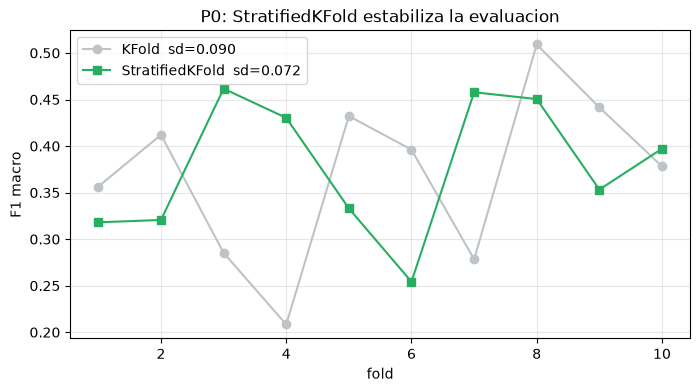

In [3]:
# Visualizamos la estabilidad: el F1 de cada uno de los 10 folds, para las dos particiones.
# Cuanto MAS plana la linea, mas estable (menos dependiente del sorteo de folds).
import matplotlib.pyplot as plt

f1_kfold = [f["f1_macro"] for f in kf["folds"]]        # F1 de cada fold (metodo viejo)
f1_strat = [f["f1_macro"] for f in sf["folds"]]        # F1 de cada fold (arreglo)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), f1_kfold, "-o", color="#bdc3c7",
         label=f"KFold  sd={kf['fold_sd']['f1_macro']:.3f}")
plt.plot(range(1, 11), f1_strat, "-s", color="#27ae60",
         label=f"StratifiedKFold  sd={sf['fold_sd']['f1_macro']:.3f}")
plt.xlabel("fold"); plt.ylabel("F1 macro")
plt.title("P0: StratifiedKFold estabiliza la evaluacion")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5. Veredicto
`StratifiedKFold` **reduce la desviación entre folds de 0.090 a 0.072** (medición más estable), con desempeño equivalente al método viejo. Queda fijado el **baseline honesto: QWK 0.415, F1 macro 0.383, MAE 0.761**.

## 6. Amenaza a la validez (limitación)
Con N=581 y solo 15 ejemplos de la clase 5, incluso el estimador estratificado tiene intervalos de confianza amplios. **Este es el techo que limita todos los experimentos siguientes**: ninguna mejora individual romperá contundentemente la barrera del ruido, salvo las que amplían los datos o corrigen la métrica. Además corrimos el baseline con 3 semillas (QWK 0.396 ± 0.020) para confirmar que no depende de un único sorteo.